In [1]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("../..") / ".env")

True

In [2]:
log = kairo.read_log("../../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    #event_id = "event:uidd",
    start_timestamp = "start:timestamp",
    resource = "org:resource",
    #event_duration = "event:runtime_min")
    )
log.head()

parsing log, completed traces :: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 32429/32429 [00:02<00:00, 11227.33it/s]


,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
0,Request created,2017-05-29 08:47:46+00:00,2017-05-29 08:49:25+00:00,6,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
1,Evaluating Request (NO registered letter),2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,7,DIRECTOR,complete,Client Recess,1 - Client lost,case_000000
2,Service closure Request with network responsib...,2017-05-29 08:56:04+00:00,2017-05-29 09:02:39+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
3,Service closure Request with BO responsibility,2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,BOF,BACK-OFFICE,complete,Client Recess,1 - Client lost,case_000000
4,Network Adjustment Requested,2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000


In [3]:
log[log["case:concept:name"] == "case_000003"]

,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
23,Request created,2017-07-11 11:05:33+00:00,2018-12-12 15:44:31+00:00,11,APPLICANT,complete,Client Recess,1 - Client lost,case_000003
24,Request deleted,2018-12-12 15:44:31+00:00,2018-12-12 15:44:31+00:00,NAN,APPLICANT,complete,Client Recess,1 - Client lost,case_000003


In [4]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 32429,
 'events': 212721,
 'activities': 15,
 'resources': 654,
 'start': Timestamp('2017-05-29 08:49:25+0000', tz='UTC'),
 'end': Timestamp('2019-03-06 16:38:59+0000', tz='UTC'),
 'span_minutes': 930709.5666666667,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 13.45629664160194,
 'tpt_days_median': 6.074346064814815,
 'tpt_days_max': 503.5870949074074,
 'length_min': 2,
 'length_mean': 6.559591723457399,
 'length_median': 7.0,
 'length_max': 23,
 'activity_counts': concept:name
 Request created                                        32377
 Service closure Request with BO responsibility         30130
 Pending Request for Reservation Closure                29151
 Request completed with account closure                 29031
 Pending Liquidation Request                            29000
 Service closure Request with network responsibility    25009
 Authorization Requested                                12675
 Evaluating Request (NO registered letter)              11080
 Back-Office Adj

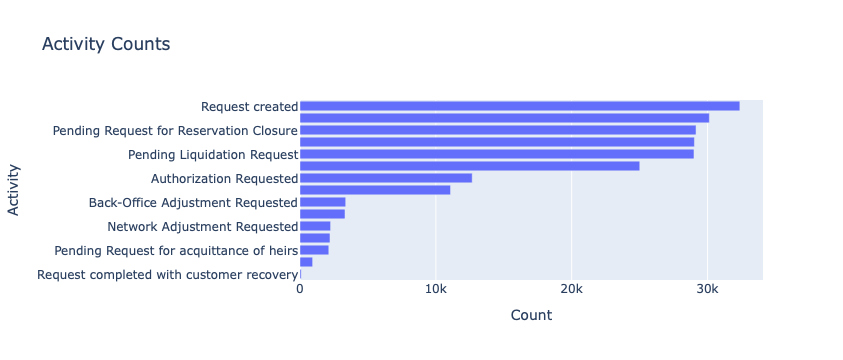

In [5]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [6]:
llm = kairo.LLMConnector(
    provider="anthropic",
    api_key=os.environ["ANTHROPIC_API_KEY"],
    model="claude-haiku-4-5-20251001"
)

response = llm.call(
    prompt="Very briefly analyze this process mining activity distribution. Do not use markdown format, just raw text",
    plots=[activity_plot],
)

response

Message(id='msg_011CfNwxFtxok8jgZG8Uo6A6', container=None, content=[TextBlock(citations=None, text='The activity distribution shows significant imbalance across the process. Request created dominates with approximately 30,000 occurrences, followed by three activities (Service closure Request with BO responsibility, Pending Request for Reservation Closure, and Request completed with account closure) clustering around 28,000-29,000 counts. These four activities represent the bulk of the process volume. Authorization Requested and Evaluating Request activities show moderate frequency at roughly 10,000-12,000 occurrences. The remaining eight activities have substantially lower counts, ranging from minimal to a few thousand. This suggests the process is heavily weighted toward initial request creation and closure-related activities, while evaluation, adjustment, and inquiry activities represent a small portion of total process instances. The tail of low-frequency activities may indicate eit

In [7]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


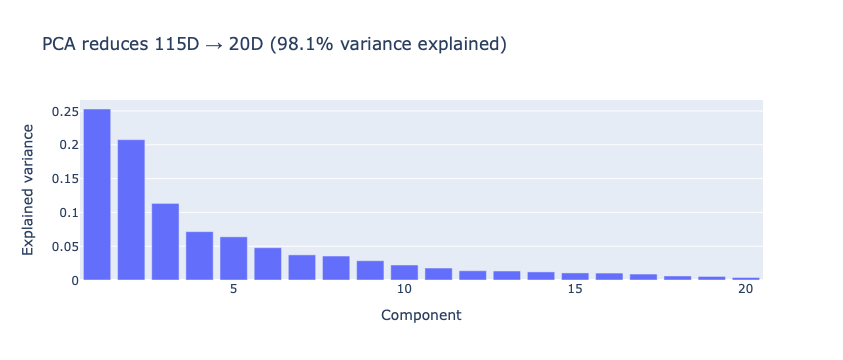

In [9]:
pca = kairo.compute_pca(std_features, num_components=20)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [10]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=13)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800


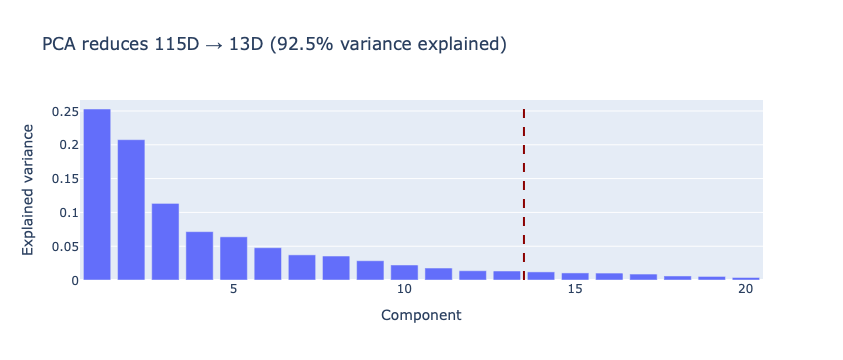

In [11]:
pca_plot = kairo.plot_pca_variances(pca, cut_component=13)
pca_plot.show()

In [12]:
som = kairo.compute_som(compressed_features, size=(10,10))
clusters = kairo.get_som_winners(compressed_features, som)
clusters

,i,j
0,3,0
1,0,0
2,9,2
3,9,9
4,8,3
...,...,...
212716,2,3
212717,2,1
212718,2,3
212719,2,1


In [ ]:
df = pd.concat([compressed_features, clusters], axis=1)
df

In [ ]:
u_matrix = kairo.plot_som_u_matrix(som)
u_matrix.show()

In [ ]:
heatmap = kairo.plot_som_heatmap(df, size=(10,10), 
                                 #start_date="2010-04-29", 
                                 #end_date="2018-05-29"
                                 )
heatmap.show()

In [ ]:
color_mapping = kairo.compute_som_color_mapping((10,10))
#color_mapping

In [ ]:
som_colors = kairo.plot_som_colors(df, color_mapping)
som_colors.show()

In [ ]:
case_trajectory = kairo.plot_case_trajectory(df, color_mapping, case_id="case_000003")
case_trajectory